In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

# --- Meteorological: hourly observations ---
WEATHER_COLS = ["temp", "rhum", "prcp", "wspd", "pres", "wdir"]
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

# --- Merge on hour ---
df = pd.merge(elec.rename(columns={"timestamp": "time"}), met, on="time", how="inner")
df = df.sort_values("time").reset_index(drop=True)

print(f"Merged range: {df['time'].min()} → {df['time'].max()}")
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Merged range: 2022-01-01 00:00:00 → 2026-03-31 23:00:00
Rows: 37,168  |  Columns: ['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres']


,time,kwh,temp,rhum,prcp,wdir,wspd,pres
0,2022-01-01 00:00:00,1.236,2.0,96,0.2,102.0,6.8,1016.0
1,2022-01-01 01:00:00,1.898,1.7,96,0.3,0.0,0.0,1015.6
2,2022-01-01 02:00:00,1.611,1.1,100,NaN,0.0,0.0,1015.3
3,2022-01-01 03:00:00,1.522,1.7,100,0.8,0.0,0.0,1015.0
4,2022-01-01 04:00:00,1.709,1.7,96,0.8,0.0,0.0,1015.0


In [2]:
# --- Time features ---
df["hour"]      = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek
df["month"]     = df["time"].dt.month

# --- Temp lag features ---
df["temp_lag1"] = df["temp"].shift(1)
df["temp_lag3"] = df["temp"].shift(3)
df["temp_lag6"] = df["temp"].shift(6)

# --- kwh lag features ---
df["kwh_lag1"] = df["kwh"].shift(1)
df["kwh_lag3"] = df["kwh"].shift(3)
df["kwh_lag6"] = df["kwh"].shift(6)

# Waking hour feature
df["awake"] = ((df["hour"] >= 6) & (df["hour"] <= 23)).astype(int)

n_rows = len(df.index)
df = df.dropna(axis=0)
print(f"Dropped: {(n_rows - len(df.index))/n_rows:0.2%} of rows")
df.head()

Dropped: 5.87% of rows


,time,kwh,temp,rhum,prcp,wdir,wspd,pres,hour,dayofweek,month,temp_lag1,temp_lag3,temp_lag6,kwh_lag1,kwh_lag3,kwh_lag6,awake
6,2022-01-01 06:00:00,1.887,1.7,96,0.0,0.0,0.0,1014.4,6,5,1,2.2,1.7,2.0,1.857,1.522,1.236,1
7,2022-01-01 07:00:00,1.959,1.7,100,0.0,0.0,0.0,1015.0,7,5,1,1.7,1.7,1.7,1.887,1.709,1.898,1
8,2022-01-01 08:00:00,2.054,1.7,96,0.0,0.0,0.0,1014.7,8,5,1,1.7,2.2,1.1,1.959,1.857,1.611,1
9,2022-01-01 09:00:00,2.014,1.7,100,0.0,0.0,0.0,1014.6,9,5,1,1.7,1.7,1.7,2.054,1.887,1.522,1
10,2022-01-01 10:00:00,1.931,1.7,100,0.0,0.0,0.0,1013.9,10,5,1,1.7,1.7,1.7,2.014,1.959,1.709,1


In [3]:
def cyclical_encode(values, period):
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

df["hour_sin"],      df["hour_cos"]      = cyclical_encode(df["hour"], 24)
df["dayofweek_sin"], df["dayofweek_cos"] = cyclical_encode(df["dayofweek"], 7)
df["month_sin"],     df["month_cos"]     = cyclical_encode(df["month"], 12)
df["wdir_sin"],      df["wdir_cos"]      = cyclical_encode(df["wdir"], 360)

In [4]:
FEATURE_COLS = [
    'temp',
    'rhum',
    'prcp',
    'wspd',
    #'pres',
    'wdir_sin',
    'wdir_cos',
    'temp_lag1',
    'temp_lag3',
    'temp_lag6',
    'kwh_lag1',
    'kwh_lag3',
    'kwh_lag6',
    #'hour_sin', 'hour_cos'
]
TARGET_COL = "kwh"

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# Sequential split to prevent data leakage
split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train_s.shape}")
print(f"X_test shape:  {X_test_s.shape}")
print(f"y_train: mean={y_train.mean():.3f} kWh, std={y_train.std():.3f}")
print(f"y_test:  mean={y_test.mean():.3f} kWh, std={y_test.std():.3f}")

Features:      ['temp', 'rhum', 'prcp', 'wspd', 'wdir_sin', 'wdir_cos', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'kwh_lag1', 'kwh_lag3', 'kwh_lag6']
X_train shape: (26239, 12)
X_test shape:  (8747, 12)
y_train: mean=1.425 kWh, std=1.292
y_test:  mean=1.735 kWh, std=1.398


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_s, y_train)

pred_kwh = lr.predict(X_test_s)

rmse = np.sqrt(mean_squared_error(y_test, pred_kwh))
r2   = r2_score(y_test, pred_kwh)

print(f"Linear Regression | R²={r2:.3f}  RMSE={rmse:.4f} kWh")

# Coefficients
coef_df = pd.DataFrame({"feature": FEATURE_COLS, "coef": lr.coef_}).sort_values("coef", key=abs, ascending=False)
print(f"\nIntercept: {lr.intercept_:.4f} kWh")
print(coef_df.to_string(index=False))

Linear Regression | R²=0.627  RMSE=0.8535 kWh

Intercept: 1.4252 kWh
  feature      coef
 kwh_lag1  0.853358
     temp -0.209367
 kwh_lag3  0.178185
 kwh_lag6 -0.071209
     rhum -0.056266
temp_lag1  0.026837
temp_lag3 -0.017758
temp_lag6  0.013564
 wdir_cos -0.008185
     wspd  0.007917
     prcp  0.004639
 wdir_sin  0.002181


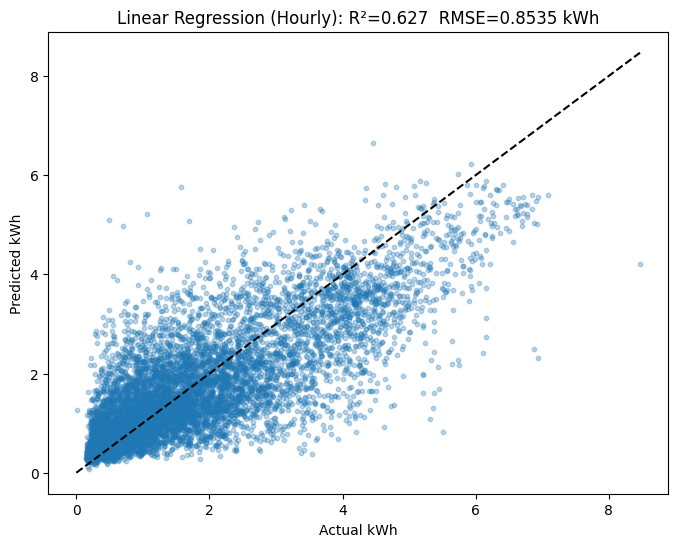

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_kwh, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'k--')
plt.xlabel('Actual kWh')
plt.ylabel('Predicted kWh')
plt.title(f'Linear Regression (Hourly): R²={r2:.3f}  RMSE={rmse:.4f} kWh')
plt.show()